# Final Tables and Figures — Manuscript Consolidation

Consolidates the already-validated outputs of notebooks 02–09 into
publication-ready tables and figures. **This notebook fits no models and
recomputes no analysis.** If an expected source file is missing, it raises
a clear error naming which upstream notebook to run — it does not attempt
to reconstruct that analysis here, which would duplicate substantial
modeling code inappropriate for a consolidation step.

**Not run here.** Written but not executed, per instruction. Run it
locally in VS Code only after notebooks 02–09 have all been run and their
outputs saved.

**Interpretation layers are kept explicitly separate throughout — never
blended into one number or one claim:**
1. **Descriptive** (B1, weighted prevalence) — association only.
2. **Predictive** (B2 + SHAP) — what the model learned; not causal.
3. **Model-based standardization** (B3) — a standardized prediction
   scenario; not a causal or counterfactual effect.
4. **Causal-style AIPW** (B4) — a selection-on-observables estimate under
   the stated confounder set; **not randomized causality**.

**This notebook does not assume the risk-stratified RD-difference finding
— it checks the actual saved confidence interval and reports honestly
whichever way it comes out**, rather than hardcoding the previously
expected "not clearly different from zero" conclusion.

## 1. Imports, paths, and a strict (fail-loudly, no-recompute) loader

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

SOURCE_TABLES_DIR = Path("../../outputs/tables")

FINAL_TABLES_DIR = Path("../../outputs/final_tables")
FINAL_FIGURES_DIR = Path("../../outputs/final_figures")
METADATA_DIR = Path("../../outputs/metadata")
for d in (FINAL_TABLES_DIR, FINAL_FIGURES_DIR, METADATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

ROUNDING_TOLERANCE_PCT = 0.05   # percentage-point tolerance for duplicated headline estimates
ROUNDING_TOLERANCE_N = 1        # count tolerance (should really be exact, but allow off-by-one)


def load_required(filename, source_notebook_hint):
    """Loads a required source CSV, or raises a clear error naming which
    upstream notebook produces it -- this notebook never recomputes."""
    path = SOURCE_TABLES_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing expected file: {path}\n"
            f"This is produced by {source_notebook_hint}. Run that notebook first -- "
            f"this consolidation notebook does not recompute analyses."
        )
    return pd.read_csv(path)


found_files = {}
missing_files = []

## 2. Load all required source tables

In [2]:
SOURCES = {
    "b1_facility_sector_prevalence": ("b1_facility_sector_prevalence.csv", "02_survey_weighted_descriptives.ipynb (B1)"),
    "b1_public_private_gap_overall": ("b1_public_private_gap_overall.csv", "02_survey_weighted_descriptives.ipynb (B1)"),
    "b1_risk_stratum_prevalence": ("b1_risk_stratum_prevalence.csv", "02_survey_weighted_descriptives.ipynb (B1)"),
    "b1_public_private_gap_by_risk_stratum": ("b1_public_private_gap_by_risk_stratum.csv", "02_survey_weighted_descriptives.ipynb (B1)"),
    "b1_facility_by_risk_stratum": ("b1_facility_by_risk_stratum.csv", "02_survey_weighted_descriptives.ipynb (B1)"),
    "b2_model_performance": ("b2_model_performance.csv", "03_v2_predictive_model_and_calibration.ipynb (B2)"),
    "b2_calibration_metrics": ("b2_calibration_metrics.csv", "03_v2_predictive_model_and_calibration.ipynb (B2)"),
    "b2_shap_original_feature_importance": ("b2_shap_original_feature_importance.csv", "05_shap_domain_attribution.ipynb"),
    "b2_shap_domain_importance": ("b2_shap_domain_importance.csv", "05_shap_domain_attribution.ipynb"),
    "b3_overall_summary": ("b3_overall_summary.csv", "07_model_based_standardization.ipynb (B3)"),
    "b3_risk_stratified_summary": ("b3_risk_stratified_summary.csv", "07_model_based_standardization.ipynb (B3)"),
    "b4_aipw_overall_summary": ("b4_aipw_overall_summary.csv", "07_aipw_primary_analysis.ipynb (B4 primary)"),
    "b4_risk_stratified_aipw_summary": ("b4_risk_stratified_aipw_summary.csv", "08_risk_stratified_aipw.ipynb (B4 stratified)"),
    "b4_sensitivity_results_consolidated": ("b4_sensitivity_results_consolidated.csv", "09_sensitivity_analyses.ipynb"),
}

data = {}
for key, (filename, hint) in SOURCES.items():
    data[key] = load_required(filename, hint)
    found_files[key] = filename

print(f"Loaded {len(data)} source tables. No analysis recomputed.")

Loaded 14 source tables. No analysis recomputed.


## 3. Consistency checks — duplicated headline estimates must match

Three genuine duplications exist across independently-computed source
files (not just topically related numbers — the same underlying quantity,
computed twice):
1. The primary AIPW summary (`b4_aipw_overall_summary.csv`) vs. its copied
   reference row inside the sensitivity-analysis table (notebook 09 loads
   and re-embeds it).
2. Facility-sector counts: B1's `n_unweighted` vs. B4's `n_private`/`n_public`
   — both computed from the same frozen `df_model_v2`, via independent
   filtering code. Both sides here are already public/private only, so this
   is a direct comparison.
3. Risk-stratum sample sizes, **public+private only**: B1's
   `b1_facility_by_risk_stratum.csv`, summed over public+private (excluding
   `other`), vs. the risk-stratified AIPW table's per-stratum N. Note this
   deliberately does **not** use `b1_risk_stratum_prevalence.csv` directly —
   that file counts all three facility sectors per stratum, while the
   risk-stratified AIPW population excludes `other` by design, so comparing
   those two directly would flag a false mismatch (exactly `other`'s count
   within that stratum, not a real inconsistency).

Any mismatch beyond the stated tolerance means something is inconsistent
between runs (a stale file, a changed filter) and **this notebook fails
loudly rather than silently reporting mismatched numbers as if they
agreed**.

In [3]:
def assert_consistent(value_a, value_b, label, tolerance):
    diff = abs(value_a - value_b)
    assert diff <= tolerance, (
        f"CONSISTENCY CHECK FAILED for '{label}': {value_a} vs {value_b} "
        f"(difference {diff} exceeds tolerance {tolerance}). "
        f"Stop -- do not proceed to publication tables until this is resolved."
    )
    print(f"OK  [{label}]: {value_a} ~= {value_b} (diff {diff:.4f}, tolerance {tolerance})")


# --- Check 1: primary AIPW summary vs. its reference row in the sensitivity table ---
primary_aipw = data["b4_aipw_overall_summary"].iloc[0]
sens = data["b4_sensitivity_results_consolidated"]
primary_reference_row = sens[sens["sensitivity"] == "0_primary_AIPW_notebook07_REFERENCE"]
assert len(primary_reference_row) == 1, \
    "Expected exactly one primary-reference row in the sensitivity table; found " + str(len(primary_reference_row))
primary_reference_row = primary_reference_row.iloc[0]

assert_consistent(primary_aipw["risk_difference_pct"], primary_reference_row["risk_difference_pct"],
                   "Primary AIPW RD (b4_aipw_overall_summary vs sensitivity reference row)", ROUNDING_TOLERANCE_PCT)
assert_consistent(primary_aipw["risk_ratio"], primary_reference_row["risk_ratio"],
                   "Primary AIPW RR (b4_aipw_overall_summary vs sensitivity reference row)", 0.01)

# --- Check 2: facility-sector counts, B1 vs B4 primary ---
b1_facility = data["b1_facility_sector_prevalence"].set_index("label")
assert_consistent(b1_facility.loc["public", "n_unweighted"], primary_aipw["n_public"],
                   "Public N (B1 vs B4 primary AIPW)", ROUNDING_TOLERANCE_N)
assert_consistent(b1_facility.loc["private", "n_unweighted"], primary_aipw["n_private"],
                   "Private N (B1 vs B4 primary AIPW)", ROUNDING_TOLERANCE_N)

# --- Check 3: risk-stratum N, public+private only, B1 vs risk-stratified AIPW ---
# NOTE: b1_risk_stratum_prevalence.csv counts ALL THREE facility sectors (public+
# private+other) within each risk stratum -- it is NOT directly comparable to the
# risk-stratified AIPW table, which excludes 'other' by design. The correct
# like-for-like comparison uses b1_facility_by_risk_stratum.csv, summed over
# public+private only, excluding 'other' on both sides.
b1_facility_by_risk = data["b1_facility_by_risk_stratum"]
risk_aipw = data["b4_risk_stratified_aipw_summary"].set_index("risk_stratum")
for stratum in ["lower_risk", "elevated_risk"]:
    b1_pub_priv_n = b1_facility_by_risk[
        (b1_facility_by_risk["risk_stratum"] == stratum)
        & (b1_facility_by_risk["facility_type"].isin(["public", "private"]))
    ]["n_unweighted"].sum()
    assert_consistent(b1_pub_priv_n, risk_aipw.loc[stratum, "n"],
                       f"{stratum} N, public+private only (B1 vs risk-stratified AIPW)", ROUNDING_TOLERANCE_N)

print("\nAll consistency checks passed.")

OK  [Primary AIPW RD (b4_aipw_overall_summary vs sensitivity reference row)]: 28.469798451314183 ~= 28.469798451314183 (diff 0.0000, tolerance 0.05)
OK  [Primary AIPW RR (b4_aipw_overall_summary vs sensitivity reference row)]: 2.7260070309880806 ~= 2.7260070309880806 (diff 0.0000, tolerance 0.01)
OK  [Public N (B1 vs B4 primary AIPW)]: 150299 ~= 150299.0 (diff 0.0000, tolerance 1)
OK  [Private N (B1 vs B4 primary AIPW)]: 50495 ~= 50495.0 (diff 0.0000, tolerance 1)
OK  [lower_risk N, public+private only (B1 vs risk-stratified AIPW)]: 79531 ~= 79531.0 (diff 0.0000, tolerance 1)
OK  [elevated_risk N, public+private only (B1 vs risk-stratified AIPW)]: 2895 ~= 2895.0 (diff 0.0000, tolerance 1)

All consistency checks passed.


## 4. Final descriptive table (B1) — association only

In [4]:
final_descriptive = data["b1_facility_sector_prevalence"][
    ["label", "n_unweighted", "weighted_prevalence_pct", "ci95_low_pct", "ci95_high_pct"]
].rename(columns={"label": "facility_sector"})
gap_row = data["b1_public_private_gap_overall"].iloc[0]
final_descriptive.attrs["public_private_gap_pct"] = gap_row["gap_pct"]
final_descriptive.attrs["public_private_gap_ci"] = (gap_row["ci95_low_pct"], gap_row["ci95_high_pct"])

final_descriptive.to_csv(FINAL_TABLES_DIR / "final_descriptive_table.csv", index=False)
print(f"Weighted public-private gap: {gap_row['gap_pct']:.2f} pts "
      f"(95% CI {gap_row['ci95_low_pct']:.2f}, {gap_row['ci95_high_pct']:.2f}) -- DESCRIPTIVE, association only.")
final_descriptive

Weighted public-private gap: 33.05 pts (95% CI 32.30, 33.80) -- DESCRIPTIVE, association only.


,facility_sector,n_unweighted,weighted_prevalence_pct,ci95_low_pct,ci95_high_pct
0,public,150299,14.31,14.01,14.62
1,private,50495,47.37,46.67,48.06
2,other,517,0.00,0.00,0.00


## 5. Final predictive performance table (B2) — predictive, not causal

In [5]:
final_predictive = data["b2_model_performance"].merge(
    data["b2_calibration_metrics"][["model", "calibration_method", "test_brier_raw", "test_brier_calibrated"]],
    on="model", how="left",
)
final_predictive.to_csv(FINAL_TABLES_DIR / "final_predictive_performance_table.csv", index=False)
final_predictive

,model,n_test,test_prevalence,pr_auc,roc_auc,precision,recall,f1_score,specificity,accuracy,brier_score_raw,calibration_method,test_brier_raw,test_brier_calibrated
0,Logistic Regression,40263,0.2223,0.5108,0.7943,0.4444,0.7073,0.5459,0.7473,0.7384,0.1861,isotonic,0.1861,0.1384
1,XGBoost,40263,0.2223,0.5334,0.8037,0.4317,0.7456,0.5468,0.7195,0.7253,0.1825,isotonic,0.1825,0.1358


## 6. Final SHAP / domain-attribution summary — predictive attribution only

In [6]:
final_shap_domain = data["b2_shap_domain_importance"].copy()
top_features = data["b2_shap_original_feature_importance"].head(10)[
    ["original_feature", "mean_abs_shap", "share_pct", "is_facility_type", "domain"]
]

final_shap_domain.to_csv(FINAL_TABLES_DIR / "final_shap_domain_summary.csv", index=False)
top_features.to_csv(FINAL_TABLES_DIR / "final_shap_top_features.csv", index=False)
print("SHAP domain shares:")
print(final_shap_domain)
print("\nTop 10 original features:")
top_features

SHAP domain shares:
                                 domain  mean_abs_shap  share_pct
0               health_service_facility       1.238925  45.553604
1  maternal_reproductive_clinical_proxy       0.959105  35.265000
2              socioeconomic_geographic       0.521678  19.181396

Top 10 original features:


,original_feature,mean_abs_shap,share_pct,is_facility_type,domain
0,facility_type,0.681260,25.049007,True,health_service_facility
1,total_children_ever_born,0.260662,9.584181,False,maternal_reproductive_clinical_proxy
2,bmi,0.246951,9.080058,False,maternal_reproductive_clinical_proxy
3,wealth_index,0.167896,6.173322,False,socioeconomic_geographic
4,anc_doctor,0.143342,5.270484,False,health_service_facility
5,age_at_first_birth,0.141405,5.199272,False,maternal_reproductive_clinical_proxy
6,education_years,0.133077,4.893059,False,socioeconomic_geographic
7,anc_visits,0.127433,4.685541,False,health_service_facility
8,social_group,0.098136,3.608314,False,socioeconomic_geographic
9,preceding_birth_interval,0.077484,2.848978,False,maternal_reproductive_clinical_proxy


## 7. Final model-based standardization summary (B3) — standardized scenario, not causal

In [7]:
final_standardization = pd.concat([
    data["b3_overall_summary"], data["b3_risk_stratified_summary"],
], ignore_index=True)
final_standardization.to_csv(FINAL_TABLES_DIR / "final_standardization_summary.csv", index=False)
final_standardization

,label,n,mean_delta_pct,median_delta_pct,p05_delta_pct,p25_delta_pct,p75_delta_pct,p95_delta_pct,mean_p_private_observed_pct,mean_p_public_set_pct,mean_delta_ci_low_pct,mean_delta_ci_high_pct,mean_p_private_ci_low_pct,mean_p_private_ci_high_pct,mean_p_public_set_ci_low_pct,mean_p_public_set_ci_high_pct
0,overall_all_private_unrestricted,10202,26.953228,26.758192,9.018517,17.868120,35.984880,45.699127,73.528524,46.575296,NaN,NaN,NaN,NaN,NaN,NaN
1,overall_common_support_PRIMARY,10122,27.053652,26.796582,9.173155,17.959261,36.039583,45.718079,73.410664,46.357012,26.801083,27.254032,73.079508,73.730629,45.889895,46.808240
2,lower_risk_common_support_PRIMARY,4604,26.874300,26.734584,9.093733,17.823570,36.064616,45.211756,76.154634,49.280334,26.593491,27.167094,75.921190,76.372011,48.784459,49.742572
3,elevated_risk_common_support_PRIMARY,162,15.232785,13.410277,6.260011,8.998880,18.213137,37.359431,88.231687,72.998902,14.769655,15.715444,87.835168,88.644386,72.312803,73.670667


## 8. Final AIPW tables (B4) — selection-on-observables causal-style, not randomized causality

In [8]:
final_aipw_overall = data["b4_aipw_overall_summary"].copy()
final_aipw_overall.to_csv(FINAL_TABLES_DIR / "final_aipw_overall_table.csv", index=False)
final_aipw_overall

,r1_hat_private_risk_pct,r0_hat_public_risk_pct,risk_difference_pct,risk_difference_ci_low_pct,risk_difference_ci_high_pct,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high,n_analytic,n_private,n_public,n_extreme_propensity,trimmed_sensitivity_rd_pct,trimmed_sensitivity_rr
0,44.9644,16.494602,28.469798,27.671957,29.244259,2.726007,2.656604,2.803453,200794,50495,150299,17501,NaN,NaN


In [9]:
final_aipw_stratified = data["b4_risk_stratified_aipw_summary"].copy()

# Check (not assume) whether the RD-difference CI includes zero.
diff_row = final_aipw_stratified[final_aipw_stratified["risk_stratum"].str.contains("difference", case=False)]
assert len(diff_row) == 1, "Expected exactly one RD-difference row in the risk-stratified AIPW table."
diff_row = diff_row.iloc[0]
ci_low, ci_high = diff_row["risk_difference_ci_low_pct"], diff_row["risk_difference_ci_high_pct"]
rd_difference_ci_includes_zero = bool(ci_low <= 0 <= ci_high)

final_aipw_stratified.to_csv(FINAL_TABLES_DIR / "final_aipw_risk_stratified_table.csv", index=False)

print(f"Lower-risk vs elevated-risk RD difference: {diff_row['risk_difference_pct']:.2f} pts "
      f"(95% CI {ci_low:.2f}, {ci_high:.2f})")
if rd_difference_ci_includes_zero:
    print("CI includes zero -- consistent with the pre-registered expectation that this difference "
          "was not clearly distinguishable from zero.")
else:
    print("NOTE: this run's CI does NOT include zero -- this differs from the previously expected "
          "finding. Do not silently report the old conclusion; investigate and update manuscript "
          "language to match this actual result.")
final_aipw_stratified

Lower-risk vs elevated-risk RD difference: 1.69 pts (95% CI -5.96, 7.74)
CI includes zero -- consistent with the pre-registered expectation that this difference was not clearly distinguishable from zero.


,risk_stratum,n,n_public,n_private,adjusted_private_risk_pct,adjusted_public_risk_pct,risk_difference_pct,risk_difference_ci_low_pct,risk_difference_ci_high_pct,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high
0,lower_risk,79531.0,56781.0,22750.0,49.385451,19.461935,29.923516,28.857777,30.963522,2.537541,2.452220,2.615615
1,elevated_risk,2895.0,1658.0,1237.0,70.607767,42.375509,28.232258,22.017372,35.792196,1.666240,1.465632,1.963221
2,lower_risk_minus_elevated_risk (RD difference),NaN,NaN,NaN,NaN,NaN,1.691257,-5.963618,7.739335,NaN,NaN,NaN


## 9. Final sensitivity-analysis table

In [10]:
final_sensitivity = data["b4_sensitivity_results_consolidated"].copy()
final_sensitivity.to_csv(FINAL_TABLES_DIR / "final_sensitivity_table.csv", index=False)
final_sensitivity

,sensitivity,n,adjusted_private_risk_pct,adjusted_public_risk_pct,risk_difference_pct,risk_difference_ci_low_pct,risk_difference_ci_high_pct,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high,n_dropped_by_trimming,rd_delta_vs_primary_pct,rr_delta_vs_primary
0,0_primary_AIPW_notebook07_REFERENCE,200794.0,44.964400,16.494602,28.469798,27.671957,29.244259,2.726007,2.656604,2.803453,NaN,0.000000,0.000000
1,1_propensity_trimming,183293.0,45.515271,16.953995,28.561276,27.775893,29.290944,2.684634,2.616037,2.757312,17501.0,0.091477,-0.041373
2,2a_ipw_only,200794.0,44.304884,16.323063,27.981821,27.085253,28.825382,2.714251,2.633704,2.796270,NaN,-0.487978,-0.011756
3,2b_outcome_regression_only,200794.0,43.915158,16.408727,27.506432,27.420222,27.608112,2.676329,2.664060,2.688777,NaN,-0.963367,-0.049678
4,3_one_birth_per_woman,158092.0,46.182891,17.432532,28.750358,27.960144,29.586816,2.649236,2.578605,2.725042,NaN,0.280560,-0.076771
5,4_refined_lower_risk,34814.0,51.135593,19.809750,31.325843,29.902880,32.731888,2.581335,2.473059,2.711102,NaN,2.856045,-0.144672
6,4_refined_elevated_risk,24394.0,57.999437,26.947880,31.051557,29.048395,33.366465,2.152282,2.054447,2.270003,NaN,2.581758,-0.573725
7,5_e_value_point_estimate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,5_e_value_ci_bound_closest_to_null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Master forest plot — primary + sensitivity RD estimates

Reuses the already-computed RD point estimates and CIs directly from the
consolidated sensitivity table (which already embeds the primary estimate
as its reference row) — no recomputation.

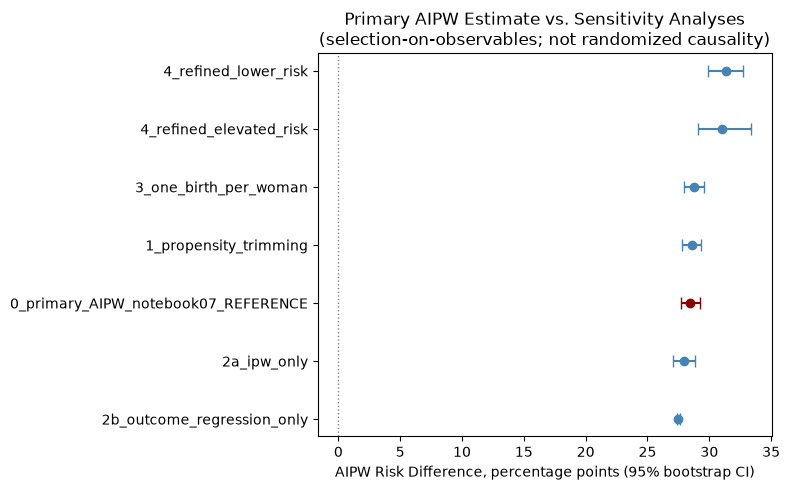

Saved: ..\..\outputs\final_figures\master_forest_plot.png


In [11]:
plot_data = final_sensitivity[~final_sensitivity["sensitivity"].str.startswith("5_e_value")].copy()
plot_data = plot_data.sort_values("risk_difference_pct")

fig, ax = plt.subplots(figsize=(8, max(5, len(plot_data) * 0.5)))
y_pos = np.arange(len(plot_data))
is_primary = plot_data["sensitivity"].str.startswith("0_primary")
colors = ["darkred" if p else "steelblue" for p in is_primary]

err_low = plot_data["risk_difference_pct"] - plot_data["risk_difference_ci_low_pct"]
err_high = plot_data["risk_difference_ci_high_pct"] - plot_data["risk_difference_pct"]

for i, (y, row, color) in enumerate(zip(y_pos, plot_data.itertuples(), colors)):
    ax.errorbar(row.risk_difference_pct, y, xerr=[[err_low.iloc[i]], [err_high.iloc[i]]],
                fmt="o", capsize=4, color=color)

ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data["sensitivity"])
ax.set_xlabel("AIPW Risk Difference, percentage points (95% bootstrap CI)")
ax.set_title("Primary AIPW Estimate vs. Sensitivity Analyses\n(selection-on-observables; not randomized causality)")
fig.tight_layout()
fig.savefig(FINAL_FIGURES_DIR / "master_forest_plot.png", dpi=200)
plt.show()
print("Saved:", FINAL_FIGURES_DIR / "master_forest_plot.png")

## 11. Headline findings figure — descriptive vs. standardization vs. causal-style, side by side

One concise figure showing how the private-vs-public estimate changes
across the analytic tiers of this project — the central "triangulation"
result. Interpretation labels are printed directly on the figure so it
cannot be read as claiming the tiers measure the same thing.

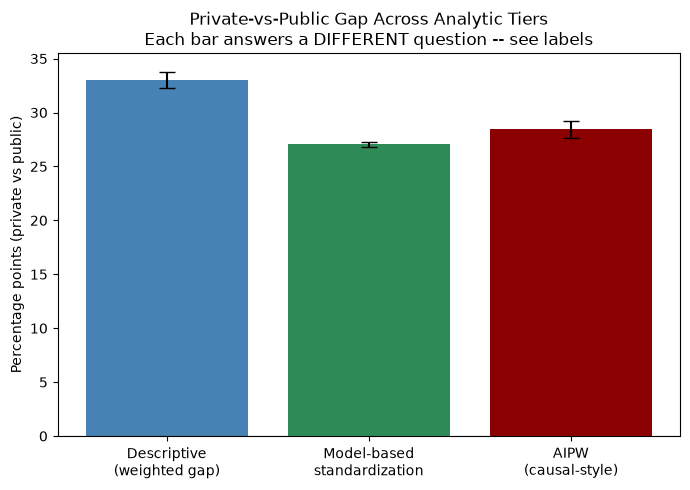

Saved: ..\..\outputs\final_figures\headline_findings_by_tier.png


In [12]:
tier_labels = ["Descriptive\n(weighted gap)", "Model-based\nstandardization", "AIPW\n(causal-style)"]
tier_values = [
    gap_row["gap_pct"],
    data["b3_overall_summary"].loc[data["b3_overall_summary"]["label"].str.contains("common_support_PRIMARY"), "mean_delta_pct"].iloc[0],
    primary_aipw["risk_difference_pct"],
]
tier_ci_low = [
    gap_row["ci95_low_pct"],
    data["b3_overall_summary"].loc[data["b3_overall_summary"]["label"].str.contains("common_support_PRIMARY"), "mean_delta_ci_low_pct"].iloc[0],
    primary_aipw["risk_difference_ci_low_pct"],
]
tier_ci_high = [
    gap_row["ci95_high_pct"],
    data["b3_overall_summary"].loc[data["b3_overall_summary"]["label"].str.contains("common_support_PRIMARY"), "mean_delta_ci_high_pct"].iloc[0],
    primary_aipw["risk_difference_ci_high_pct"],
]
err = [[v - lo for v, lo in zip(tier_values, tier_ci_low)], [hi - v for v, hi in zip(tier_values, tier_ci_high)]]

fig, ax = plt.subplots(figsize=(7, 5))
x_pos = np.arange(len(tier_labels))
ax.bar(x_pos, tier_values, yerr=err, capsize=6, color=["steelblue", "seagreen", "darkred"])
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(tier_labels)
ax.set_ylabel("Percentage points (private vs public)")
ax.set_title("Private-vs-Public Gap Across Analytic Tiers\nEach bar answers a DIFFERENT question -- see labels")
fig.tight_layout()
fig.savefig(FINAL_FIGURES_DIR / "headline_findings_by_tier.png", dpi=200)
plt.show()
print("Saved:", FINAL_FIGURES_DIR / "headline_findings_by_tier.png")

## 12. `master_results.csv` — one compact file of every headline number

In [13]:
master_rows = [
    {"metric": "descriptive_weighted_gap_pct", "value": gap_row["gap_pct"],
     "ci_low": gap_row["ci95_low_pct"], "ci_high": gap_row["ci95_high_pct"], "interpretation_layer": "descriptive"},
    {"metric": "predictive_xgboost_pr_auc",
     "value": final_predictive.loc[final_predictive["model"] == "XGBoost", "pr_auc"].iloc[0],
     "ci_low": np.nan, "ci_high": np.nan, "interpretation_layer": "predictive"},
    {"metric": "predictive_xgboost_roc_auc",
     "value": final_predictive.loc[final_predictive["model"] == "XGBoost", "roc_auc"].iloc[0],
     "ci_low": np.nan, "ci_high": np.nan, "interpretation_layer": "predictive"},
    {"metric": "shap_top_domain_share_pct", "value": final_shap_domain["share_pct"].max(),
     "ci_low": np.nan, "ci_high": np.nan, "interpretation_layer": "predictive"},
    {"metric": "standardization_overall_mean_delta_pct",
     "value": data["b3_overall_summary"].loc[data["b3_overall_summary"]["label"].str.contains("common_support_PRIMARY"), "mean_delta_pct"].iloc[0],
     "ci_low": data["b3_overall_summary"].loc[data["b3_overall_summary"]["label"].str.contains("common_support_PRIMARY"), "mean_delta_ci_low_pct"].iloc[0],
     "ci_high": data["b3_overall_summary"].loc[data["b3_overall_summary"]["label"].str.contains("common_support_PRIMARY"), "mean_delta_ci_high_pct"].iloc[0],
     "interpretation_layer": "model_based_standardization"},
    {"metric": "aipw_overall_risk_difference_pct", "value": primary_aipw["risk_difference_pct"],
     "ci_low": primary_aipw["risk_difference_ci_low_pct"], "ci_high": primary_aipw["risk_difference_ci_high_pct"],
     "interpretation_layer": "causal_style_aipw"},
    {"metric": "aipw_overall_risk_ratio", "value": primary_aipw["risk_ratio"],
     "ci_low": primary_aipw["risk_ratio_ci_low"], "ci_high": primary_aipw["risk_ratio_ci_high"],
     "interpretation_layer": "causal_style_aipw"},
    {"metric": "aipw_lower_risk_rd_pct",
     "value": risk_aipw.loc["lower_risk", "risk_difference_pct"],
     "ci_low": risk_aipw.loc["lower_risk", "risk_difference_ci_low_pct"],
     "ci_high": risk_aipw.loc["lower_risk", "risk_difference_ci_high_pct"], "interpretation_layer": "causal_style_aipw"},
    {"metric": "aipw_elevated_risk_rd_pct",
     "value": risk_aipw.loc["elevated_risk", "risk_difference_pct"],
     "ci_low": risk_aipw.loc["elevated_risk", "risk_difference_ci_low_pct"],
     "ci_high": risk_aipw.loc["elevated_risk", "risk_difference_ci_high_pct"], "interpretation_layer": "causal_style_aipw"},
    {"metric": "aipw_rd_difference_lower_minus_elevated_pct", "value": diff_row["risk_difference_pct"],
     "ci_low": ci_low, "ci_high": ci_high, "interpretation_layer": "causal_style_aipw"},
]
master_results = pd.DataFrame(master_rows)
master_results["rd_difference_ci_includes_zero"] = np.where(
    master_results["metric"] == "aipw_rd_difference_lower_minus_elevated_pct", rd_difference_ci_includes_zero, np.nan,
)
master_results.to_csv(FINAL_TABLES_DIR / "master_results.csv", index=False)
print(f"Saved master_results.csv: {master_results.shape}")
master_results

Saved master_results.csv: (10, 6)


,metric,value,ci_low,ci_high,interpretation_layer,rd_difference_ci_includes_zero
0,descriptive_weighted_gap_pct,33.050000,32.300000,33.800000,descriptive,NaN
1,predictive_xgboost_pr_auc,0.533400,NaN,NaN,predictive,NaN
2,predictive_xgboost_roc_auc,0.803700,NaN,NaN,predictive,NaN
3,shap_top_domain_share_pct,45.553604,NaN,NaN,predictive,NaN
4,standardization_overall_mean_delta_pct,27.053652,26.801083,27.254032,model_based_standardization,NaN
5,aipw_overall_risk_difference_pct,28.469798,27.671957,29.244259,causal_style_aipw,NaN
6,aipw_overall_risk_ratio,2.726007,2.656604,2.803453,causal_style_aipw,NaN
7,aipw_lower_risk_rd_pct,29.923516,28.857777,30.963522,causal_style_aipw,NaN
8,aipw_elevated_risk_rd_pct,28.232258,22.017372,35.792196,causal_style_aipw,NaN
9,aipw_rd_difference_lower_minus_elevated_pct,1.691257,-5.963618,7.739335,causal_style_aipw,1.0


## 13. Save metadata

In [14]:
metadata = {
    "source_files": {key: str(SOURCE_TABLES_DIR / filename) for key, (filename, _) in SOURCES.items()},
    "missing_source_files": missing_files,
    "consistency_checks": "All passed -- see Section 3 output for exact values and tolerances.",
    "headline_estimates": master_results.set_index("metric")["value"].to_dict(),
    "rd_difference_lower_vs_elevated_ci_includes_zero": rd_difference_ci_includes_zero,
    "interpretation_layers": {
        "descriptive": "B1 survey-weighted prevalence -- association only",
        "predictive": "B2 + SHAP -- what the model learned; not causal",
        "model_based_standardization": "B3 -- standardized prediction scenario; not a causal or counterfactual effect",
        "causal_style_aipw": "B4 -- selection-on-observables estimate under the stated confounder set; NOT randomized causality",
    },
    "randomized_causality_claimed": False,
}

with open(METADATA_DIR / "final_results_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", METADATA_DIR / "final_results_metadata.json")

Saved: ..\..\outputs\metadata\final_results_metadata.json


## 14. Final Report

**Four interpretation layers, kept separate as required:**
1. **Descriptive** — the raw weighted public-private gap (Section 4). Pure
   association.
2. **Predictive** — B2's model performance and SHAP attribution
   (Sections 5–6). Describes what the model learned; implies nothing about
   mechanism.
3. **Model-based standardization** — B3's standardized delta (Section 7).
   A "what would the model predict if facility sector were flipped"
   scenario, not a causal claim.
4. **Causal-style AIPW** — B4's adjusted Risk Difference and Risk Ratio
   (Section 8), overall and by risk stratum. Selection-on-observables under
   the stated confounder set. **Not randomized causality** — credible only
   to the extent that confounder set is sufficient (see notebooks 06–07 for
   the documented exclusions).

**On the risk-stratified RD difference:** Section 8 above computed —
rather than assumed — whether the lower-risk-vs-elevated-risk RD
difference's 95% CI includes zero. Check the printed output and
`rd_difference_lower_vs_elevated_ci_includes_zero` in the metadata file
before writing manuscript language about this comparison; this notebook
reports whichever way that check actually comes out, not a hardcoded
expectation.

**Every consistency check in Section 3 either passed (and printed
confirmation) or the notebook stopped with a loud, specific error** —
there is no path through this notebook that silently reports mismatched
duplicated numbers as if they agreed.

**Outputs:** `outputs/final_tables/` (7 tables + `master_results.csv`),
`outputs/final_figures/` (2 figures), `outputs/metadata/final_results_metadata.json`.